
# **TMS 2025 AI Workshop: Ryan Jacobs, Ben Afflerbach, Dane Morgan (UW-Madison)**

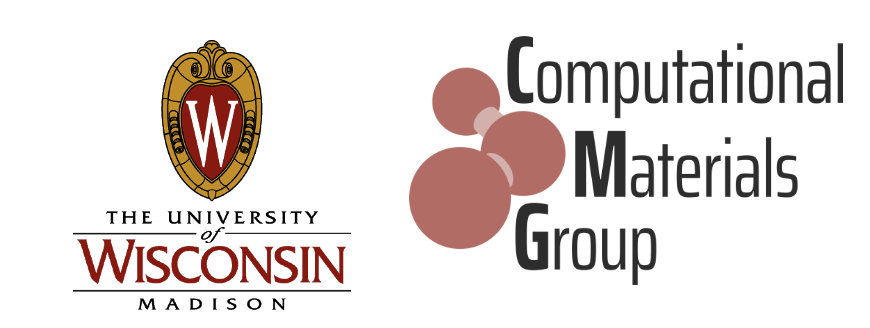

---


## Google Colab notebook demo of structure based property prediction:
## Fine tuning for prediction Na-battery material voltage

# Part 1: Installation and setup

To begin, we need to install needed python dependencies to run [ALIGNN](https://github.com/usnistgov/alignn)

We'll checkout and install a slightly older branch of the code that is compatible with the current Google Colab Environment

In [1]:
%%time
import os
os.chdir('/content')
# Clone ALIGNN repo to get example folder
if not os.path.exists('alignn'):
   !git clone https://github.com/atomgptlab/alignn.git
os.chdir("alignn")

!git checkout v2024.12.12
!pip install -q --no-cache-dir dgl -f https://data.dgl.ai/wheels/torch-2.4/cu124/repo.html
!pip install -e .
os.chdir('/content')

Cloning into 'alignn'...
remote: Enumerating objects: 5336, done.
remote: Counting objects: 100% (538/538), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 5336 (delta 519), reused 496 (delta 492), pack-reused 4798 (from 1)
Receiving objects: 100% (5336/5336), 155.13 MiB | 14.17 MiB/s, done.
Resolving deltas: 100% (3251/3251), done.
Note: switching to 'v2024.12.12'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at b4b68c5 Merge pull request #179 from usnistgov/develop
     ━━━━━━━━━━━━━━━━━━

CPU times: user 3.32 s, sys: 911 ms, total: 4.23 s
Wall time: 2min 24s


In [1]:
!pip install pymatgen mp_api

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 128.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.4/264.4 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.7/123.7 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 6.7 MB/s eta 0:00:00


Double check that we have the ALIGNN code with example dataset

In [2]:
import os
!pwd
os.chdir('/content')
# Clone ALIGNN repo to get example folder
if not os.path.exists('alignn'):
  !git clone https://github.com/usnistgov/alignn.git

os.chdir('alignn')

/content


# Part 2: Training and Predicting using sample POSCAR data

ALIGNN github package comes with an example dataset. let's do a quick test with that to check things are working and installed correctly

The example data we'll work with is configured as a directory of POSCAR files. Additionally it must contain a file "id_prop.csv" which is a two two column csv with file names matching the POSCAR files paired with the property value of interest. The example dataset is a set of Band Gap values.

In [3]:
!ls "alignn/examples/sample_data"

config_example.json	  POSCAR-JVASP-64045.vasp  POSCAR-JVASP-86097.vasp
id_prop.csv		  POSCAR-JVASP-64240.vasp  POSCAR-JVASP-86205.vasp
POSCAR-JVASP-107772.vasp  POSCAR-JVASP-64377.vasp  POSCAR-JVASP-86436.vasp
POSCAR-JVASP-10.vasp	  POSCAR-JVASP-64584.vasp  POSCAR-JVASP-86726.vasp
POSCAR-JVASP-13526.vasp   POSCAR-JVASP-64664.vasp  POSCAR-JVASP-86968.vasp
POSCAR-JVASP-1372.vasp	  POSCAR-JVASP-64719.vasp  POSCAR-JVASP-89025.vasp
POSCAR-JVASP-14014.vasp   POSCAR-JVASP-64906.vasp  POSCAR-JVASP-89265.vasp
POSCAR-JVASP-14441.vasp   POSCAR-JVASP-65062.vasp  POSCAR-JVASP-90228.vasp
POSCAR-JVASP-14873.vasp   POSCAR-JVASP-65101.vasp  POSCAR-JVASP-90532.vasp
POSCAR-JVASP-15345.vasp   POSCAR-JVASP-655.vasp    POSCAR-JVASP-90856.vasp
POSCAR-JVASP-1996.vasp	  POSCAR-JVASP-676.vasp    POSCAR-JVASP-97378.vasp
POSCAR-JVASP-21210.vasp   POSCAR-JVASP-76308.vasp  POSCAR-JVASP-97499.vasp
POSCAR-JVASP-22556.vasp   POSCAR-JVASP-76309.vasp  POSCAR-JVASP-97570.vasp
POSCAR-JVASP-27901.vasp   POSCAR-JVASP-76312.

sample structure of the id_prop.csv file

In [4]:
!head "alignn/examples/sample_data/id_prop.csv"

POSCAR-JVASP-90856.vasp,0.000000
POSCAR-JVASP-86097.vasp,0.000000
POSCAR-JVASP-64906.vasp,0.000000
POSCAR-JVASP-98225.vasp,0.472000
POSCAR-JVASP-10.vasp,0.000000
POSCAR-JVASP-14014.vasp,0.000000
POSCAR-JVASP-64664.vasp,0.000000
POSCAR-JVASP-22556.vasp,0.000000
POSCAR-JVASP-86726.vasp,0.000000
POSCAR-JVASP-28634.vasp,0.689000


The last file in the sample data folder is config_example.json

This configuration file sets various aspects of the dataset from model architecture details, to training parameters.

To interact with it I'll suggest double clicking from the file explorer on the left of the Google Colab interface to inspect and view directly rather than reading in the json file to Python

To perform a training run we'll use the train_alignn.py script. Any configuration tags specified in the call will overwrite the defaults in the config file.

In [5]:
!train_alignn.py --root_dir "alignn/examples/sample_data" \
                 --epochs 10 \
                 --batch_size 16 \
                 --config "alignn/examples/sample_data/config_example.json" \
                 --output_dir="sample_test"

DGL backend not selected or invalid.  Assuming PyTorch for now.
Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)
/content/alignn/alignn/train.py:42: SyntaxWarning: invalid escape sequence '\ '
  / \  | |   |_ _/ ___| \ | | \ | |
world_size 1
root_dir alignn/examples/sample_data
id_prop_csv_file exists True
len dataset 50
train_stress False
Using LMDB dataset.
MAX val: 6.149
MIN val: 0.0
MAD: 1.0520696
Baseline MAE: 2.3805500000000004
data range 4.907 0.0
line_graph True
100% 40/40 [00:00<00:00, 60.07it/s]
data range 1.569 0.0
line_graph True
100% 5/5 [00:00<00:00, 66.94it/s]
data range 6.149 0.0
line_graph True
100% 5/5 [00:00<00:00, 52.36it/s]
n_train: 40
n_val  : 5
n_test : 5
rank 0
world_size 1
config: {'version': '112bbedebdaecf59fb18e11c929080fb2f358246', 'dataset': 'user_data', 'target': 'target', 'atom_features': 'cgcnn', 'neighb

In [ ]:
!ls

alignn		 Atrain_data	  LICENSE.rst	  sample_test
alignn.egg-info  Aval_data	  pyproject.toml  setup.py
Atest_data	 environment.yml  README.md


To use the trainined model we can load model checkpoints from the output directory

In [ ]:
import torch
from alignn.models.alignn_atomwise import ALIGNNAtomWise , ALIGNNAtomWiseConfig

output_directory = 'sample_test/'
output_features =  1
filename = os.path.join(output_directory,'best_model.pt')
device = "cpu"
if torch.cuda.is_available():
    device = torch.device("cuda")

from jarvis.db.jsonutils import loadjson
# load config from output folder
config=loadjson(os.path.join(output_directory,'config.json'))

model = ALIGNNAtomWise(ALIGNNAtomWiseConfig(**config["model"]))
model.load_state_dict(torch.load(filename, map_location=device))
model.eval()

/tmp/ipython-input-3046456322.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(filename, map_location=device))


ALIGNNAtomWise(
  (atom_embedding): MLPLayer(
    (layer): Sequential(
      (0): Linear(in_features=92, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (2): SiLU()
    )
  )
  (edge_embedding): Sequential(
    (0): RBFExpansion()
    (1): MLPLayer(
      (layer): Sequential(
        (0): Linear(in_features=80, out_features=64, bias=True)
        (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (2): SiLU()
      )
    )
    (2): MLPLayer(
      (layer): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (2): SiLU()
      )
    )
  )
  (angle_embedding): Sequential(
    (0): RBFExpansion()
    (1): MLPLayer(
      (layer): Sequential(
        (0): Linear(in_features=40, out_features=64, bias=True)
        (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (2): SiLU()
      )
    )
    (2): MLPLayer(
     

To make predictions we load a POSCAR file and build a graph representation

In [ ]:
from jarvis.core.atoms import Atoms
from alignn.graphs import Graph
cutoff = 8.0
model=model.to(device)
max_neighbors = 12
# pick one of the sample data files for this quick demo
atoms = Atoms.from_poscar('alignn/examples/sample_data/POSCAR-JVASP-10.vasp')
g, lg = Graph.atom_dgl_multigraph(atoms, cutoff=float(cutoff), max_neighbors=max_neighbors)
lat = torch.tensor(atoms.lattice_mat)
out_data = (
    model([g.to(device), lg.to(device),lat.to(device)])['out']
    .detach()
    .cpu()
    .numpy()
    .flatten()
    .tolist()[0]
)

print ('output: ', out_data)

output:  -5.067168712615967


In [ ]:
atoms = atoms.make_supercell([2, 2, 2])
g, lg = Graph.atom_dgl_multigraph(atoms)
lat = torch.tensor(atoms.lattice_mat)
out_data = (
    model([g.to(device), lg.to(device),lat.to(device)])['out']
    .detach()
    .cpu()
    .numpy()
    .flatten()
    .tolist()[0]
)
print("supercell", out_data)

supercell -5.09176778793335


Let's look at the model performance across the test dataset

In [ ]:
from jarvis.db.jsonutils import loadjson
import pandas as pd

d=loadjson(os.path.join(output_directory,'Test_results.json'))
x=[i['target_out'][0] for i in d]
y=[i['pred_out'] for i in d]
ids=[i['id'] for i in d]

we can convert to csv for later

In [ ]:
# Create a DataFrame to save the results in csv for later
data = {'id': ids, 'target': x, 'prediction': y}
df = pd.DataFrame(data)

# Save the DataFrame as a CSV file
csv_file = 'ben_test/prediction_results_test_set.csv'
df.to_csv(csv_file, index=False)

OSError: Cannot save file into a non-existent directory: 'ben_test'

MAE 2.0524492800235747


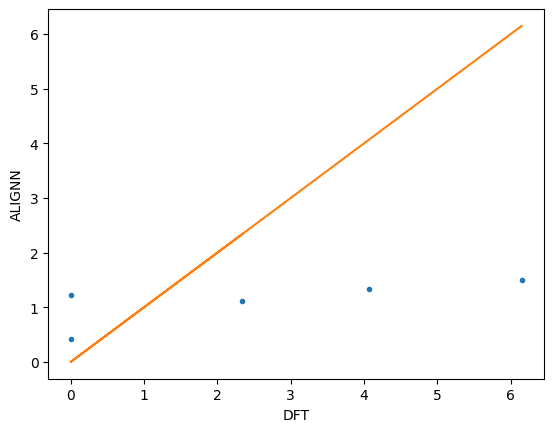

In [ ]:
import matplotlib.pyplot as plt
plt.plot(x,y,'.')
plt.plot(x,x)
plt.xlabel('DFT')
plt.ylabel('ALIGNN')

from sklearn.metrics import mean_absolute_error
print('MAE',mean_absolute_error(x,y))

In [ ]:
df

,id,target,prediction
0,POSCAR-JVASP-21210.vasp,6.149,1.497660
1,POSCAR-JVASP-97677.vasp,4.072,1.331338
2,POSCAR-JVASP-65101.vasp,0.000,1.227506
3,POSCAR-JVASP-65062.vasp,0.000,0.416722
4,POSCAR-JVASP-97570.vasp,2.341,1.114984


# Part 3: Obtaining Voltage Data

The data file contains U-MLIP relaxed structures and average voltages for 2288 materials. Let's plot a histogram of the computed average voltages to see their distribution:

In [6]:
import joblib
import pandas as pd
import numpy as np
import os
from pymatgen.core import Structure, Composition
import matplotlib.pyplot as plt

import sys

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## UPDATE: currently link into a local shortcut to the TMS_2025_AI_workshop folder. Is this our overall strategy? Any better ideas?

In [8]:
d = '/content/drive/MyDrive/TMS_2025_AI_workshop'

df = joblib.load(os.path.join(d, 'mp_Na_eqV2.pkl'))

df.head()

,index,"Relaxed structure, full","Relaxed structure, empty","Relaxed structure, ref","Relaxed energy, full","Relaxed energy, empty","Relaxed energy, ref","Relaxed volume, full","Relaxed volume, empty",Average voltage (V/ion),mp_id,Composition,Structure
0,0,"{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...",-47.144470,-42.739342,-2.612235,86.925992,82.302897,3.099011,mp-1002571-GGA+U,NaMn2O4,"[[ 1.4537295 -0.858677 2.8019015] Na, [0. 0...."
1,0,"{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...",-347.147003,-342.174774,-2.612235,580.632428,580.309435,3.666111,mp-1003635-GGA+U,NaMn16O32,"[[4.97042764 4.96925164 4.40963713] Na, [6.467..."
2,0,"{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...",-360.532379,-342.138519,-2.612235,592.342169,578.011476,3.292347,mp-1003636-GGA+U,NaMn4O8,"[[3.75601408 7.43825464 1.65457529] Na, [ 5.16..."
3,0,"{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...",-351.932495,-342.103943,-2.612235,585.379022,583.089731,3.608158,mp-1003638-GGA+U,NaMn8O16,"[[-4.9288659 5.00872719 -1.47329048] Na, [-9..."
4,0,"{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...",-93.682617,-84.215996,-2.612235,162.257705,136.842690,3.427193,mp-1003766-GGA+U,NaMn2O4,"[[1.46205272 2.17082951 8.89991039] Na, [1.462..."


In [9]:
def plot_voltage_histogram(df, dataset='MP', ion='Na'):
    bins = np.arange(0, 10, 0.2)

    # Matterverse avg voltage has a bunch of negative values- remove them!
    df = df[df['Average voltage (V/ion)'] >=0]

    plt.clf()

    plt.hist(bins=bins, x=df['Average voltage (V/ion)'], color='red', edgecolor='black', alpha=0.5, label='EquiformerV2')

    plt.xlabel('Average voltage (V/Na)', fontsize=14)
    plt.xticks(fontsize=12)
    plt.ylabel('Number of occurrences', fontsize=14)
    plt.yticks(fontsize=12)
    plt.legend(loc='best')
    plt.savefig('Voltage_histogram_'+dataset+'_'+ion+'.png', dpi=300, bbox_inches='tight')

    vals = df['Average voltage (V/ion)']
    print('EquiformerV2 stats')
    print(np.mean(vals), np.std(vals), min(vals), max(vals))

    return

EquiformerV2 stats
4.1346677545044805 0.9164283551284464 0.5237773656845093 6.9161494970321655


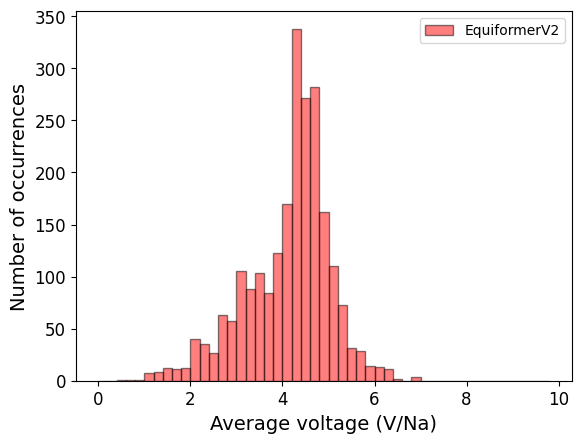

In [10]:
plot_voltage_histogram(df)

# Part 4: Creating the input data structure


In [11]:
import os

# Create the directory if it doesn't exist
output_dir = 'voltage_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Create a list to store the filenames
filenames = []

# Iterate through the DataFrame and save each structure as a POSCAR file
for i, structure in enumerate(df['Structure']):
    filename = f'POSCAR_{i}.vasp'
    structure.to(os.path.join(output_dir,filename))
    filenames.append(filename)

# Add the filenames as a new column to the DataFrame
df['poscar_filename'] = filenames

print(f"Saved {len(df)} POSCAR files to the '{output_dir}' directory and added filenames to the DataFrame.")

Saved 2288 POSCAR files to the 'voltage_data' directory and added filenames to the DataFrame.


create our id_prop.csv

In [12]:
output_file = os.path.join(output_dir, 'id_prop.csv')

# Select the required columns and save to a CSV file without headers
df[['poscar_filename', 'Average voltage (V/ion)']].to_csv(output_file, index=False, header=False)

print(f"Saved id and property data to '{output_file}'.")

Saved id and property data to 'voltage_data/id_prop.csv'.


copy the previously used config file

In [13]:
import os
import shutil

source_config_path = 'alignn/examples/sample_data/config_example.json'
destination_config_path = 'voltage_data/config.json'

# Ensure the destination directory exists (already created in a previous step)
output_dir = 'voltage_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Copy the config file
shutil.copyfile(source_config_path, destination_config_path)

print(f"Copied '{source_config_path}' to '{destination_config_path}'")

Copied 'alignn/examples/sample_data/config_example.json' to 'voltage_data/config.json'


In [14]:
from jarvis.db.jsonutils import loadjson
# import os

config_path = 'voltage_data/config.json'
config = loadjson(config_path)
print("Config file loaded successfully.")

Config file loaded successfully.


In [15]:
from jarvis.db.jsonutils import dumpjson

config['filename'] = 'V'
print("Updated config['filename'] to:", config['filename'])

config_path = 'voltage_data/config.json'
dumpjson(config,config_path)
print(f"Updated config saved to '{config_path}'")

Updated config['filename'] to: V
Updated config saved to 'voltage_data/config.json'


# Part 5: Creating a Na voltage property predictor

with these setting on a T4 each epoch takes ~1 minute  
10 epochs expected to take 10 minutes in example below

In [18]:
!train_alignn.py --root_dir 'voltage_data' \
                --epochs 100 \
                --batch_size 16 \
                --config './voltage_data/config.json' \
                --output_dir=voltage_output


world_size 1
root_dir voltage_data
id_prop_csv_file exists True
len dataset 2288
train_stress False
Using LMDB dataset.
MAX val: 6.9161494970321655
MIN val: 0.5237773656845093
MAD: 0.7039226796506327
Baseline MAE: 0.6280776675249891
data range 6.9161494970321655 0.5237773656845093
line_graph True
100% 1830/1830 [02:31<00:00, 12.10it/s]
data range 5.940403342247009 1.0945152044296265
line_graph True
100% 228/228 [00:10<00:00, 22.38it/s]
data range 6.241167426109314 1.2685588598251343
line_graph True
100% 228/228 [00:10<00:00, 21.72it/s]
n_train: 1830
n_val  : 228
n_test : 228
rank 0
world_size 1
config: {'version': '112bbedebdaecf59fb18e11c929080fb2f358246', 'dataset': 'user_data', 'target': 'target', 'atom_features': 'cgcnn', 'neighbor_strategy': 'k-nearest', 'id_tag': 'jid', 'dtype': 'float32', 'random_seed': 123, 'classification_threshold': None, 'n_val': None, 'n_test': None, 'n_train': None, 'train_ratio': 0.8, 'val_ratio': 0.1, 'test_ratio': 0.1, 'target_multiplication_factor': No

Let's visualize the performance

In [19]:
import torch
from alignn.models.alignn_atomwise import ALIGNNAtomWise , ALIGNNAtomWiseConfig
output_features =  1
filename = 'voltage_output/best_model.pt'
device = "cpu"
if torch.cuda.is_available():
    device = torch.device("cuda")

from jarvis.db.jsonutils import loadjson
# load config from output folder
config=loadjson('voltage_output/config.json')

model = ALIGNNAtomWise(ALIGNNAtomWiseConfig(**config["model"]))
model.load_state_dict(torch.load(filename, map_location=device))
model.eval()

/tmp/ipython-input-1323077064.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(filename, map_location=device))


ALIGNNAtomWise(
  (atom_embedding): MLPLayer(
    (layer): Sequential(
      (0): Linear(in_features=92, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (2): SiLU()
    )
  )
  (edge_embedding): Sequential(
    (0): RBFExpansion()
    (1): MLPLayer(
      (layer): Sequential(
        (0): Linear(in_features=80, out_features=64, bias=True)
        (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (2): SiLU()
      )
    )
    (2): MLPLayer(
      (layer): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (2): SiLU()
      )
    )
  )
  (angle_embedding): Sequential(
    (0): RBFExpansion()
    (1): MLPLayer(
      (layer): Sequential(
        (0): Linear(in_features=40, out_features=64, bias=True)
        (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (2): SiLU()
      )
    )
    (2): MLPLayer(
     

In [20]:
d=loadjson('voltage_output/Test_results.json')
x=[i['target_out'][0] for i in d]
y=[i['pred_out'] for i in d]
ids=[i['id'] for i in d]

In [21]:
# Create a DataFrame
data = {'id': ids, 'target': x, 'prediction': y}
voltage_df = pd.DataFrame(data)

# Save the DataFrame as a CSV file
csv_file = 'voltage_output/prediction_results_test_set.csv'
voltage_df.to_csv(csv_file, index=False)

In [23]:
voltage_df.head()

,id,target,prediction
0,POSCAR_2060.vasp,4.593880,4.860487
1,POSCAR_2061.vasp,3.754155,3.661666
2,POSCAR_2062.vasp,4.421426,4.329108
3,POSCAR_2063.vasp,2.703572,3.122346
4,POSCAR_2064.vasp,4.796662,4.744101


MAE 0.18909347371051186


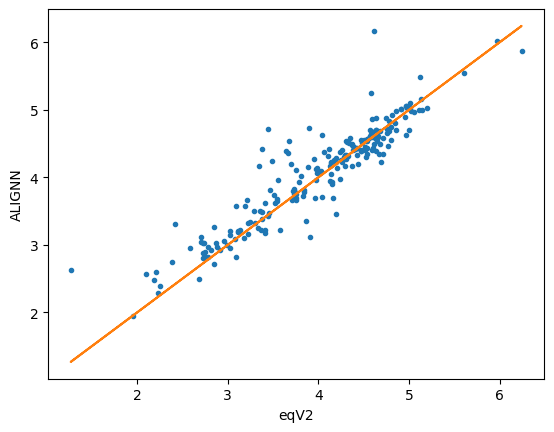

In [24]:
import matplotlib.pyplot as plt
plt.plot(x,y,'.')
plt.plot(x,x)
plt.xlabel('eqV2')
plt.ylabel('ALIGNN')

from sklearn.metrics import mean_absolute_error
print('MAE',mean_absolute_error(x,y))

# Part 6:  Investigate a particular structure

In [ ]:
from jarvis.core.atoms import Atoms
from alignn.graphs import Graph
cutoff = 8.0
model=model.to(device)
max_neighbors = 12
# pick one of the sample data files for this
atoms = Atoms.from_poscar('voltage_data/POSCAR_0.vasp')

In [ ]:
g, lg = Graph.atom_dgl_multigraph(atoms, cutoff=float(cutoff), max_neighbors=max_neighbors)
lat = torch.tensor(atoms.lattice_mat)
out_data = (
    model([g.to(device), lg.to(device),lat.to(device)])['out']
    .detach()
    .cpu()
    .numpy()
    .flatten()
    .tolist()[0]
)

print ('predicted Average Voltage (V/ion): ', round(out_data,3))

predicted Average Voltage (V/ion):  3.129


In [ ]:
atoms

System
1.0
3.0456479300000003 0.0 0.0
-0.3048584 5.19552989 0.0
-0.10911434 -1.73452754 5.65984103
Na Mn O 
1 2 4 
direct
0.5 -0.0 0.5 Na
0.0 0.0 0.0 Mn
0.5 0.5 0.0 Mn
0.474597 0.7839010000000001 0.824565 O
0.035903 0.24902 0.809991 O
0.964097 0.75098 0.190009 O
0.525403 0.216099 0.175435 O

In [ ]:
print('Reference Average Voltage (V/ion): ', round(df['Average voltage (V/ion)'][0],3))

Reference Average Voltage (V/ion):  3.099


Let's apply 1% strain to the structure?
Ryan ideas for things that could be physically motivated here? General thought it manipulate the structure and see if the model predictions react as we would expect

In [ ]:
atoms = atoms.strain_atoms(0.01)
g, lg = Graph.atom_dgl_multigraph(atoms)
lat = torch.tensor(atoms.lattice_mat)
out_data = (
    model([g.to(device), lg.to(device),lat.to(device)])['out']
    .detach()
    .cpu()
    .numpy()
    .flatten()
    .tolist()[0]
)
print ('predicted Average Voltage (V/ion): ', round(out_data,3))

predicted Average Voltage (V/ion):  3.046
